In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt


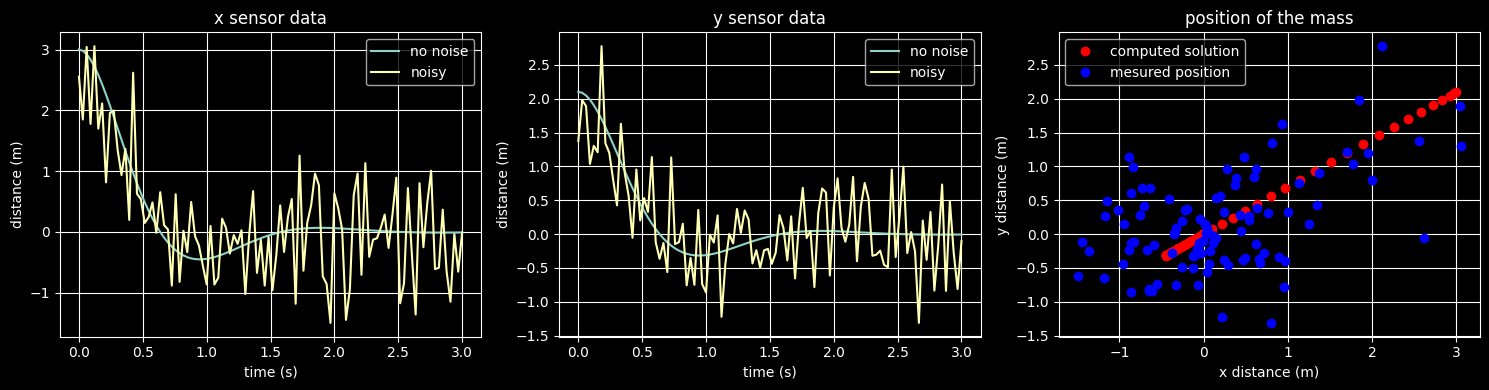

In [5]:
#Ayoub Dimensional reduction
#initial condition of the oscilator

m = 1
c=4
k=15
tau = 2*m/c
w= np.sqrt((k/m)-((c/(2*m))**2))
# Choosen initial state
x0= 3
y0= 2.1
v0=0
# Computed parameters from the initial state
A0= 4.27
phi=-0.54
#generate the data
t = np.linspace(0,6*tau,100)
N=len(t)
x_th= A0*np.cos(np.deg2rad(35))*np.exp((-1/tau)*t)*np.cos(w*t + phi)
y_th= A0*np.sin(np.deg2rad(35))*np.exp((-1/tau)*t)*np.cos(w*t + phi)
# Noisy
sigma_x = 0.20 * (A0 * np.cos(np.deg2rad(35)))
sigma_y = 0.20 * (A0 * np.sin(np.deg2rad(35)))
x = np.random.normal(x_th, sigma_x)
y = np.random.normal(y_th, sigma_y)
dt_matrice = np.column_stack((x, y))


fig, (ax1, ax2,ax3) = plt.subplots(1,3, figsize=(15, 4))
# Graph 1
ax1.plot(t, x_th, label='no noise')
ax1.plot(t, x, label='noisy')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('distance (m)')
ax1.set_title('x sensor data')
ax1.legend()
ax1.grid(True)

# Graph 2
ax2.plot(t, y_th, label='no noise')
ax2.plot(t, y, label='noisy')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('distance (m)')
ax2.set_title('y sensor data')
ax2.legend()
ax2.grid(True)

# Graph
ax3.plot(x_th, y_th,'ro', label='computed solution')
ax3.plot(x, y, 'bo',label='mesured position')
ax3.set_xlabel('x distance (m)')
ax3.set_ylabel('y distance (m)')
ax3.set_title('position of the mass')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()





(100, 100)
(2,)
(2, 2)
(100, 2)


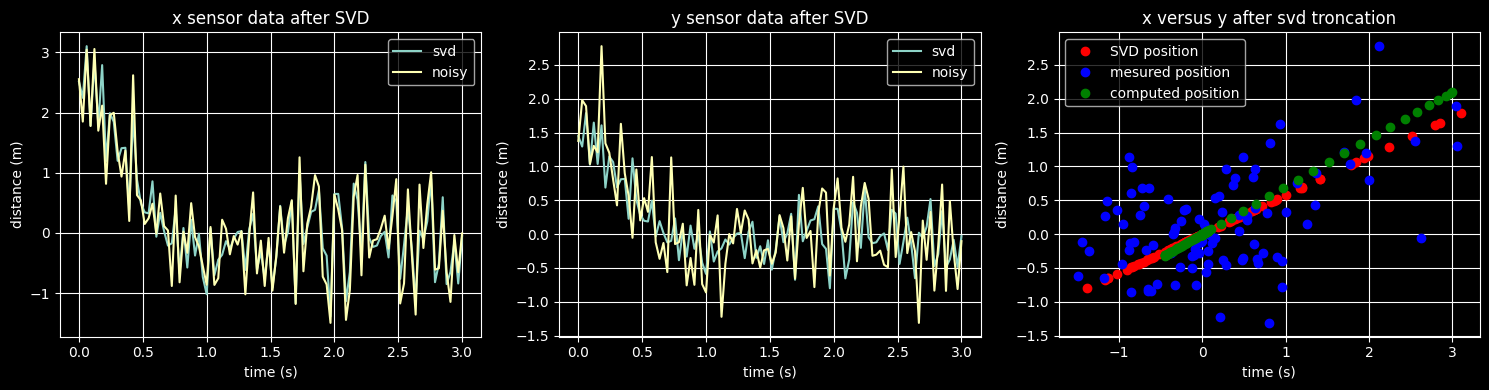

In [6]:
#SVD
U,S,V = np.linalg.svd(dt_matrice)
print(U.shape)
print(S.shape)
print(V.shape)
#I take the first eigenvalue only
mapprox = np.outer(U[:, 0] * S[0], V[0, :])
x_troncted_svd= mapprox[:,0]
y_troncted_svd= mapprox[:,1]
print(mapprox.shape)
fig, (ax1_svd, ax2_svd,ax3_svd) = plt.subplots(1,3, figsize=(15, 4))
# Graph 1
ax1_svd.plot(t, x_troncted_svd, label='svd')
ax1_svd.plot(t, x, label='noisy')
ax1_svd.set_xlabel('time (s)')
ax1_svd.set_ylabel('distance (m)')
ax1_svd.set_title('x sensor data after SVD')
ax1_svd.legend()
ax1_svd.grid(True)

# Graph 2
ax2_svd.plot(t, y_troncted_svd, label='svd')
ax2_svd.plot(t, y, label='noisy')
ax2_svd.set_xlabel('time (s)')
ax2_svd.set_ylabel('distance (m)')
ax2_svd.set_title('y sensor data after SVD')
ax2_svd.legend()
ax2_svd.grid(True)

# Graph
ax3_svd.plot(x_troncted_svd, y_troncted_svd,'ro', label='SVD position')
ax3_svd.plot(x, y, 'bo',label='mesured position')
ax3_svd.plot(x_th, y_th, 'go',label='computed position')
ax3_svd.set_xlabel('time (s)')
ax3_svd.set_ylabel('distance (m)')
ax3_svd.set_title('x versus y after svd troncation')
ax3_svd.legend()
ax3_svd.grid(True)

plt.tight_layout()
plt.show()


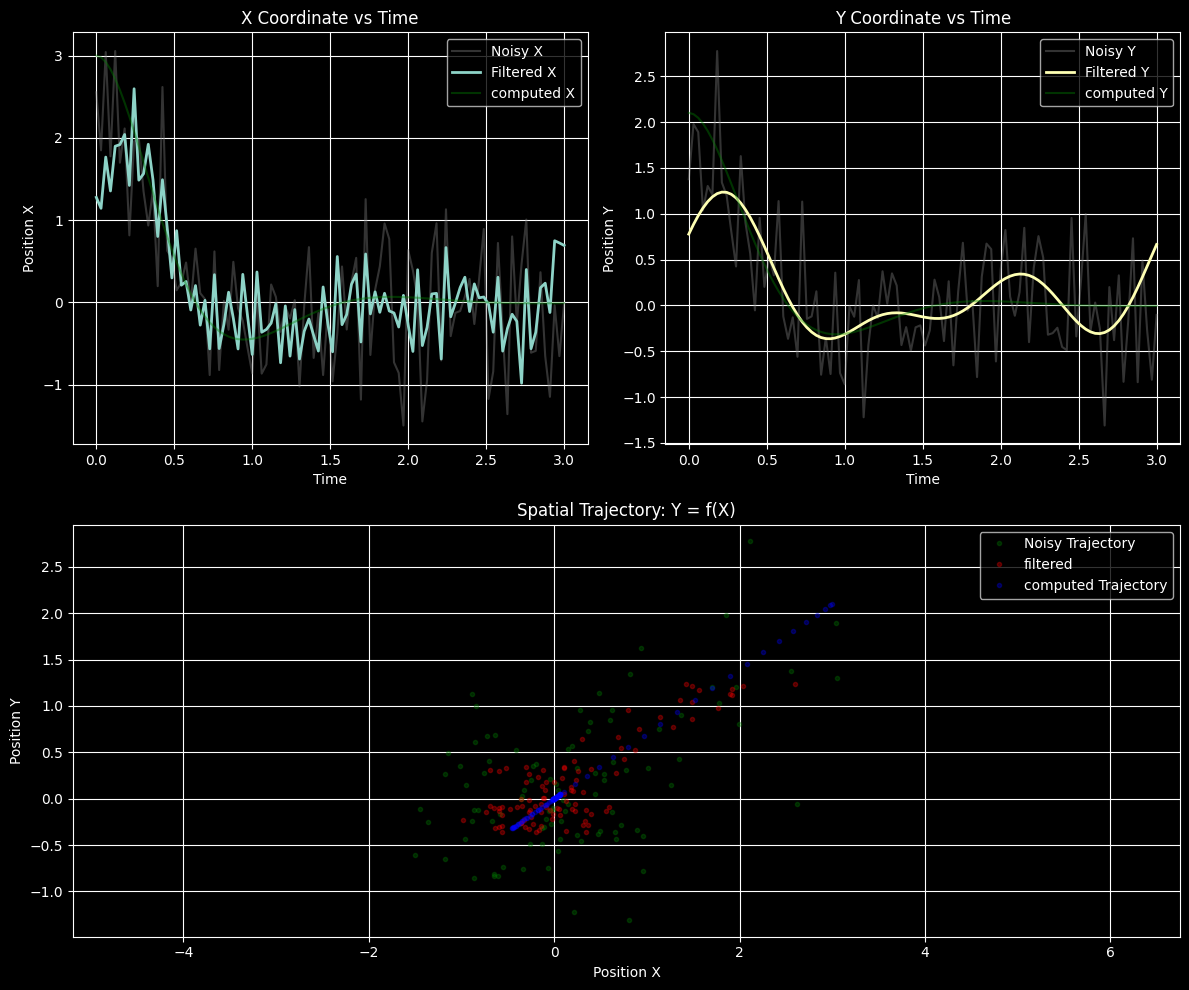

In [7]:
#DFT
# --- 1. Fast Fourier Transform ---
# axis=0 is mandatory to treat columns as independent signals
dft = np.fft.fft(dt_matrice, axis=0)

# --- 2. Direct Threshold Filtering ---
# Strategy: Zero out any component below 10% of the peak magnitude
# This is a one-liner "Hard Thresholding" filter
dft[np.abs(dft) < 0.4 * np.max(np.abs(dft))] = 0

# --- 3. Immediate Reconstruction ---
# .real converts back from complex after the inverse transform
clean_data = np.fft.ifft(dft, axis=0).real

fig = plt.figure(figsize=(12, 10))

# Subplot 1: X over Time
ax1 = plt.subplot(2, 2, 1)
ax1.plot(t, x, color='gray', alpha=0.4, label='Noisy X')
ax1.plot(t, clean_data[:, 0], color='C0', linewidth=2, label='Filtered X')
ax1.plot(t, x_th, color='green', alpha=0.4, label='computed X')
ax1.set_title('X Coordinate vs Time')
ax1.set_xlabel('Time')
ax1.set_ylabel('Position X')
ax1.legend()
ax1.grid(True)

# Subplot 2: Y over Time
ax2 = plt.subplot(2, 2, 2)
ax2.plot(t, y, color='gray', alpha=0.4, label='Noisy Y')
ax2.plot(t, clean_data[:, 1], color='C1', linewidth=2, label='Filtered Y')
ax2.plot(t, y_th, color='green', alpha=0.4, label='computed Y')
ax2.set_title('Y Coordinate vs Time')
ax2.set_xlabel('Time')
ax2.set_ylabel('Position Y')
ax2.legend()
ax2.grid(True)

# Subplot 3: Trajectory (X vs Y) - Spanning the bottom row
ax3 = plt.subplot(2, 1, 2)
ax3.plot(x, y, 'go', alpha=0.3, markersize=3, label='Noisy Trajectory')
ax3.plot(clean_data[:, 0], clean_data[:, 1],'ro', alpha=0.3, markersize=3, label='filtered')
ax3.plot(x_th, y_th, 'bo', alpha=0.3, markersize=3, label='computed Trajectory')
ax3.set_title('Spatial Trajectory: Y = f(X)')
ax3.set_xlabel('Position X')
ax3.set_ylabel('Position Y')
# Important: Set equal aspect ratio to avoid geometric distortion
ax3.set_aspect('equal', 'datalim')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

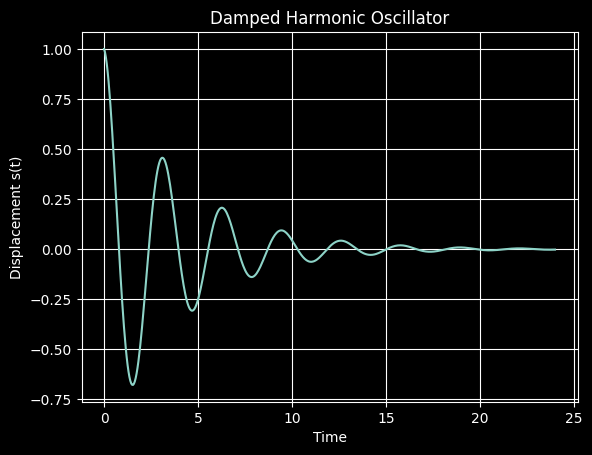

In [8]:
"""
Walid : dimensionality reduction
"""

# 1.Construct an underdamped harmonic oscillator with your choice of characteristic frequency and starting conditions.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Physical parameters
# -----------------------------
m = 1.0        # mass
k = 4.0        # spring constant
c = 0.5        # damping coefficient (underdamped case)

# Check underdamped condition
assert c < 4 * m * k, "System is not underdamped!"

# -----------------------------
# 2. Signal parameters
# -----------------------------
A0 = 1.0       # initial amplitude
phi = 0.0      # initial phase

# Damped natural frequency
omega = np.sqrt(k/m - (c/(2*m))**2)

# Characteristic time
tau = 2 * m / c

# Time vector (simulate up to 6 tau)
t_max = 6 * tau
N = 500
t = np.linspace(0, t_max, N)

# -----------------------------
# 3. Analytical solution
# -----------------------------
s = A0 * np.exp(-c/(2*m) * t) * np.cos(omega * t + phi)

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure()
plt.plot(t, s)
plt.title("Damped Harmonic Oscillator")
plt.xlabel("Time")
plt.ylabel("Displacement s(t)")
plt.grid()
plt.show()

Shape of X: (2, 500)


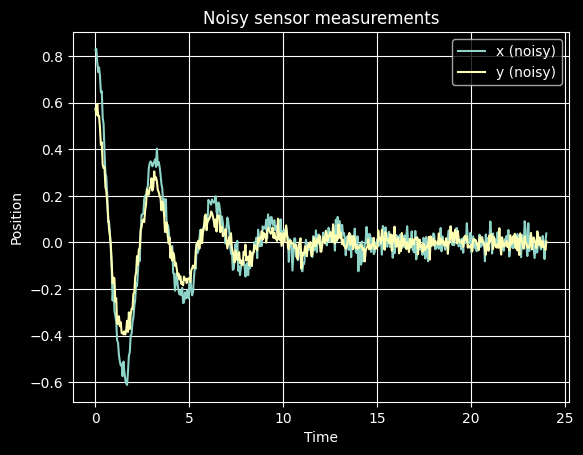

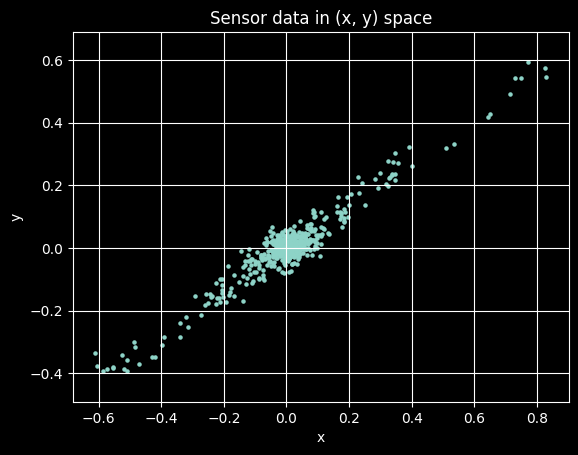

In [9]:
"""
2.Build a synthetic dataset by pretending that the position of the mass is tracked in time by two sensors in the x,y directions. Each sensor has a 20 %
uncertainty (random white noise) and the angle between the s and x axis is equal to θ = 35°, as reported in Figure below. Collect the position for 6τ,
where τ = 2m/c is the characteristic time length.
"""

# -----------------------------
# 5. Projection into (x, y)
# -----------------------------
theta_deg = 35
theta = np.deg2rad(theta_deg)  # convert to radians

x = s * np.cos(theta)
y = s * np.sin(theta)

# -----------------------------
# 6. Add 20% Gaussian noise
# -----------------------------
noise_level = 0.2

# Noise scaled with signal standard deviation
x_noisy = x + noise_level * np.std(x) * np.random.randn(len(x))
y_noisy = y + noise_level * np.std(y) * np.random.randn(len(y))

# -----------------------------
# 7. Build data matrix X
# -----------------------------
# Shape = (2, N)
X = np.vstack((x_noisy, y_noisy))

print("Shape of X:", X.shape)

# -----------------------------
# 8. Visualization
# -----------------------------
plt.figure()
plt.plot(t, x_noisy, label="x (noisy)")
plt.plot(t, y_noisy, label="y (noisy)")
plt.title("Noisy sensor measurements")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()
plt.grid()
plt.show()

# Scatter plot (phase-like view)
plt.figure()
plt.scatter(x_noisy, y_noisy, s=5)
plt.title("Sensor data in (x, y) space")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()
plt.show()

Singular values: [4.7006323  0.60752415]
Energy of modes: [0.98357066 0.01642934]


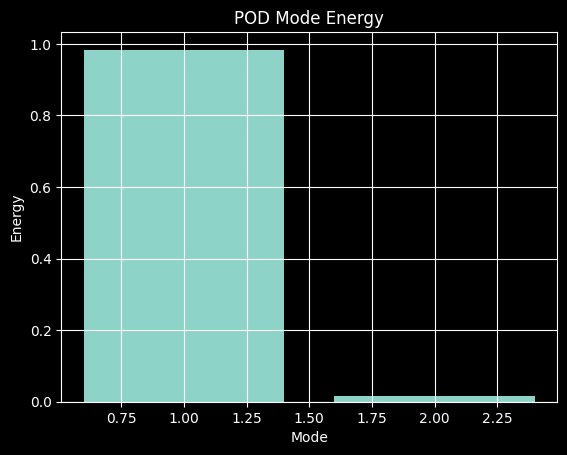

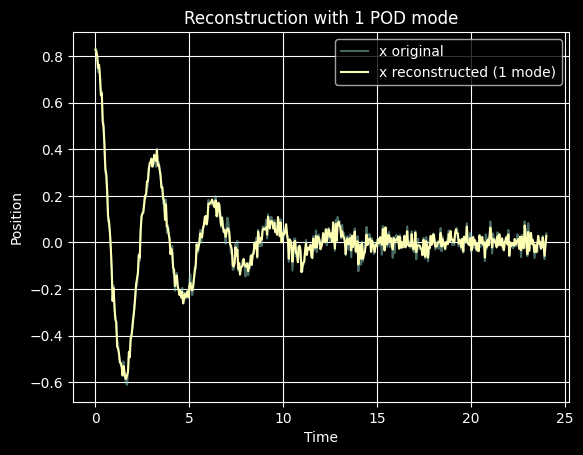

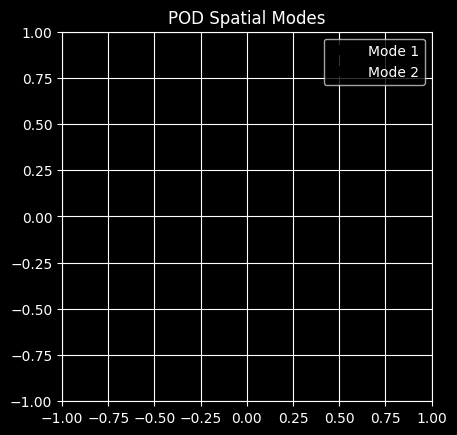

In [10]:
"""
3.Apply the POD and DFT algorithms to the data matrix X containing the x and y positions. To perform the POD and DFT, you can use the standard python libraries
(numpy.linalg.svd() for the SVD algorithm and numpy.fft.fft() to perform the DFT). Or, you can use the modulo-vki package that you can find here, along with the
instruction for the installation and the documentation.
"""
# -----------------------------
# 9. Apply POD (SVD)
# -----------------------------
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# -----------------------------
# 10. Energy analysis of modes
# -----------------------------
# Compute normalized energy of each mode
energy = S**2 / np.sum(S**2)

print("Singular values:", S)
print("Energy of modes:", energy)

# -----------------------------
# 11. Plot energy distribution
# -----------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.bar(range(1, len(energy)+1), energy)
plt.title("POD Mode Energy")
plt.xlabel("Mode")
plt.ylabel("Energy")
plt.grid()
plt.show()

# -----------------------------
# 12. Reconstruction using 1 mode
# -----------------------------
# Rank-1 approximation
X_reconstructed_1 = U[:, :1] @ np.diag(S[:1]) @ Vt[:1, :]

# -----------------------------
# 13. Full reconstruction (2 modes)
# -----------------------------
X_reconstructed_2 = U @ np.diag(S) @ Vt

# -----------------------------
# 14. Compare original vs reconstructed signal
# -----------------------------
plt.figure()
plt.plot(t, X[0, :], label="x original", alpha=0.5)
plt.plot(t, X_reconstructed_1[0, :], label="x reconstructed (1 mode)")
plt.title("Reconstruction with 1 POD mode")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 15. Plot spatial modes
# -----------------------------
plt.figure()
plt.quiver(0, 0, U[0, 0], U[1, 0], angles='xy', scale_units='xy', scale=1, label="Mode 1")
plt.quiver(0, 0, U[0, 1], U[1, 1], angles='xy', scale_units='xy', scale=1, label="Mode 2")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("POD Spatial Modes")
plt.legend()
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

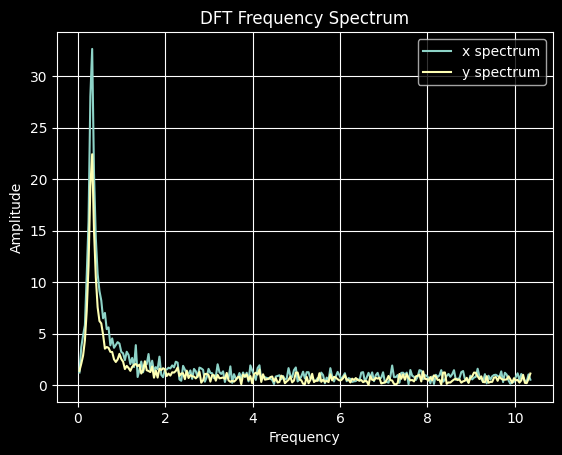

In [11]:
"""
4.Compare the POD and DFT results.
"""

# -----------------------------
# 16. Apply DFT (Fourier Transform)
# -----------------------------

# Sampling step
dt = t[1] - t[0]

# FFT of both signals
X_fft = np.fft.fft(X, axis=1)
freqs = np.fft.fftfreq(X.shape[1], d=dt)

# -----------------------------
# 17. Keep only positive frequencies
# -----------------------------
positive_freqs = freqs > 0

freqs_pos = freqs[positive_freqs]

x_fft_magnitude = np.abs(X_fft[0, positive_freqs])
y_fft_magnitude = np.abs(X_fft[1, positive_freqs])

# -----------------------------
# 18. Plot frequency spectrum
# -----------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.plot(freqs_pos, x_fft_magnitude, label="x spectrum")
plt.plot(freqs_pos, y_fft_magnitude, label="y spectrum")
plt.title("DFT Frequency Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()